In [ ]:
import os
path='/content/drive/MyDrive/PREDICT-COCA_seg/data_resampled'
print(len(os.listdir(path)))

69


In [ ]:
!pip install nibabel

In [ ]:
import os

img_paths = []

for root, dirs, files in os.walk(path):
    for f in files:
        if f.endswith("_img.nii.gz"):
            img_paths.append(os.path.join(root, f))

print("Total scans:", len(img_paths))
print(img_paths[:3])

Total scans: 69
['/content/drive/MyDrive/PREDICT-COCA_seg/data_resampled/6c155d7b3ad5/6c155d7b3ad5_img.nii.gz', '/content/drive/MyDrive/PREDICT-COCA_seg/data_resampled/61aa61a02290/61aa61a02290_img.nii.gz', '/content/drive/MyDrive/PREDICT-COCA_seg/data_resampled/d460b3282183/d460b3282183_img.nii.gz']


In [ ]:
import os

img_paths = []

for root, dirs, files in os.walk(path):
    for f in files:
        if f.endswith("_img.nii.gz"):
            img_paths.append(os.path.join(root, f))

print("Total scans:", len(img_paths))
print(img_paths[:3])

CALCIUM SEGMENTATION BASELINE MODEL TRAINING. GROUND TRUTH'S BEING DERIVED FROM COCA DATASET.

In [ ]:
import os
import cv2
import numpy as np
import nibabel as nib
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from scipy.ndimage import label

TARGET = 192
NEG_RATIO = 0.05

def roi_crop_3d(img, seg, margin=10):

    body_mask = img > -300

    labeled, num = label(body_mask)
    if num > 1:
        sizes = np.bincount(labeled.ravel())
        sizes[0] = 0
        body_mask = labeled == np.argmax(sizes)

    coords = np.where(body_mask)
    if len(coords[0]) == 0:
        return img, seg

    x_min, x_max = coords[0].min(), coords[0].max()
    y_min, y_max = coords[1].min(), coords[1].max()
    z_min, z_max = coords[2].min(), coords[2].max()

    H, W, D = img.shape

    x_center_min = int(H * 0.25)
    x_center_max = int(H * 0.75)
    y_center_min = int(W * 0.20)
    y_center_max = int(W * 0.70)

    x_min = max(x_min, x_center_min)
    x_max = min(x_max, x_center_max)
    y_min = max(y_min, y_center_min)
    y_max = min(y_max, y_center_max)

    x_min = max(0, x_min - margin)
    y_min = max(0, y_min - margin)
    z_min = max(0, z_min - margin)

    x_max = min(H, x_max + margin)
    y_max = min(W, y_max + margin)
    z_max = min(D, z_max + margin)

    return (img[x_min:x_max, y_min:y_max, z_min:z_max],
            seg[x_min:x_max, y_min:y_max, z_min:z_max])


def extract_slices(paths):

    images, masks = [], []

    for p in paths:

        img = nib.load(p).get_fdata()
        seg = nib.load(p.replace("_img", "_seg")).get_fdata()

        img, seg = roi_crop_3d(img, seg)

        pos_slices = []
        neg_slices = []

        for z in range(img.shape[2]):
            if np.sum(seg[:, :, z]) > 0:
                pos_slices.append(z)
            else:
                neg_slices.append(z)

        if len(neg_slices) > 0:
            n_neg = int(len(neg_slices) * NEG_RATIO)
            neg_sample = np.random.choice(neg_slices, size=n_neg, replace=False)
        else:
            neg_sample = []

        # sample positives
        pos_sample = np.random.choice(
            pos_slices,
            size=min(len(pos_slices), 20),
            replace=False
        )

        # sample negatives
        neg_sample = np.random.choice(
            neg_slices,
            size=min(len(neg_slices), 5),
            replace=False
        )

        selected = list(pos_sample) + list(neg_sample)

        for z in selected:
            im = img[:, :, z]
            ma = seg[:, :, z]

            im = cv2.resize(im, (TARGET, TARGET))
            ma = cv2.resize(ma, (TARGET, TARGET), interpolation=cv2.INTER_NEAREST)

            hu_mask = (im > 130).astype(np.float32)

            im = np.clip(im, -120, 1024)

            im = (im + 120) / (1024 + 120)
            im = np.stack([im, hu_mask], axis=0)
            images.append(im.astype(np.float32))
            masks.append((ma > 0).astype(np.float32))

    return np.stack(images), np.stack(masks)


train_paths, val_paths = train_test_split(
    img_paths,
    test_size=0.2,
    random_state=42
)

print("Train patients:", len(train_paths))
print("Val patients:", len(val_paths))

X_train, y_train = extract_slices(train_paths)
X_val, y_val = extract_slices(val_paths)

print("Train slices:", X_train.shape)
print("Val slices:", X_val.shape)

y_train = np.expand_dims(y_train, 1)
y_val = np.expand_dims(y_val, 1)

X_train = torch.tensor(X_train)
y_train = torch.tensor(y_train)
X_val = torch.tensor(X_val)
y_val = torch.tensor(y_val)

train_ds = TensorDataset(X_train, y_train)
val_ds = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=4)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train patients: 55
Val patients: 14
Train slices: (705, 2, 192, 192)
Val slices: (234, 2, 192, 192)
Train batches: 177
Val batches: 59


In [ ]:
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from ipywidgets import interact

# pick a random patient
p = train_paths[np.random.randint(len(train_paths))]

img = np.asarray(nib.load(p).dataobj, dtype=np.float32)
seg = np.asarray(nib.load(p.replace("_img","_seg")).dataobj, dtype=np.float32)

img_crop, seg_crop = roi_crop_3d(img, seg)

print("Original shape:", img.shape)
print("Cropped shape:", img_crop.shape)

def view_slice(z):

    mask_present = np.sum(seg_crop[:,:,z]) > 0

    plt.figure(figsize=(14,5))

    # Cropped CT
    plt.subplot(1,2,1)
    plt.imshow(img_crop[:,:,z], cmap="gray")
    plt.title(f"CT Slice {z}")
    plt.axis("off")

    # Overlay mask
    plt.subplot(1,2,2)
    plt.imshow(img_crop[:,:,z], cmap="gray")
    plt.imshow(seg_crop[:,:,z], cmap="jet", alpha=0.6)

    if mask_present:
        label = "Calcium Present"
        color = "red"
    else:
        label = "No Calcium"
        color = "green"

    plt.title(label)
    plt.text(10,20,label,color=color,fontsize=14,weight='bold')
    plt.axis("off")

    plt.show()

interact(view_slice, z=(0, img_crop.shape[2]-1))

Original shape: (285, 285, 220)
Cropped shape: (162, 162, 220)


interactive(children=(IntSlider(value=109, description='z', max=219), Output()), _dom_classes=('widget-interac…

<function __main__.view_slice(z)>

In [ ]:
X_train = torch.tensor(X_train)
y_train = torch.tensor(y_train)

X_val = torch.tensor(X_val)
y_val = torch.tensor(y_val)

/tmp/ipykernel_341/1883278357.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train)
/tmp/ipykernel_341/1883278357.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train)
/tmp/ipykernel_341/1883278357.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_val = torch.tensor(X_val)
/tmp/ipykernel_341/1883278357.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than to

In [ ]:
print("Train batches:", len(train_loader))

Train batches: 177


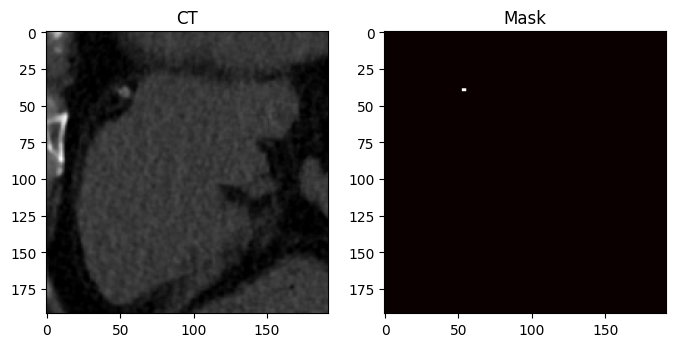

In [ ]:
idx = np.random.randint(len(X_train))

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(X_train[idx][0], cmap="gray")
plt.title("CT")

plt.subplot(1,2,2)
plt.imshow(y_train[idx][0], cmap="hot")
plt.title("Mask")

plt.show()

In [ ]:
import torch
import torch.nn as nn


# Residual Block

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)

        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_ch)

        # adjust channels if needed
        if in_ch != out_ch:
            self.skip = nn.Conv2d(in_ch, out_ch, 1)
        else:
            self.skip = nn.Identity()

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):

        identity = self.skip(x)

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        out = out + identity
        out = self.relu(out)

        return out


# Residual UNet

class ResUNet(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = ResBlock(2, 32)
        self.enc2 = ResBlock(32, 64)
        self.enc3 = ResBlock(64, 128)

        self.pool = nn.MaxPool2d(2)

        # Decoder
        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec2 = ResBlock(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.dec1 = ResBlock(64, 32)

        # Output
        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        # Decoder
        d2 = self.up2(e3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)

In [ ]:
import torch
import torch.nn as nn
device = "cuda" if torch.cuda.is_available() else "cpu"

def dice(pred, target, smooth=1e-6):

    pred = torch.sigmoid(pred)

    pred = pred.view(pred.size(0), -1)
    target = target.view(target.size(0), -1)

    intersection = (pred * target).sum(dim=1)
    union = pred.sum(dim=1) + target.sum(dim=1)

    dice_score = (2. * intersection + smooth) / (union + smooth)

    return dice_score.mean()

def dice_loss(pred, target):
    return 1 - dice(pred, target)

bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([20.0]).to(device))

def combined_loss(pred, target):
    pred_sigmoid=torch.sigmoid(pred)
    return 0.1 * bce(pred, target) + 0.9 * dice_loss(pred_sigmoid, target)

In [ ]:
!pip install sympy==1.12

In [ ]:
import importlib
import sympy
importlib.reload(sympy)

<module 'sympy' from '/usr/local/lib/python3.12/dist-packages/sympy/__init__.py'>

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = ResUNet().to(device)
opt = torch.optim.Adam(model.parameters(), lr=3e-5)

best_dice = 0
SAVE_PATH = "/content/drive/MyDrive/PREDICT-COCA_seg/coca_unet_best_8_march.pth"

EPOCHS = 1500

for epoch in range(EPOCHS):

    # TRAIN
    model.train()
    train_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        pred = model(x)
        loss = combined_loss(pred, y)

        opt.zero_grad()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        loss.backward()
        opt.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # VALIDATION
    model.eval()
    val_dice = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            pred = model(x)
            pred = torch.sigmoid(pred)
            pred = (pred > 0.3).float()

            val_dice += dice(pred, y).item()

    val_dice /= len(val_loader)

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Dice: {val_dice:.4f}")

    # SAVE BEST MODEL
    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), SAVE_PATH)
        print("Best model saved.")

Epoch 01 | Train Loss: 0.9771 | Val Dice: 0.0517
Best model saved.
Epoch 02 | Train Loss: 0.9216 | Val Dice: 0.0518
Best model saved.
Epoch 03 | Train Loss: 0.9097 | Val Dice: 0.0519
Best model saved.
Epoch 04 | Train Loss: 0.8970 | Val Dice: 0.0518
Epoch 05 | Train Loss: 0.8833 | Val Dice: 0.0520
Best model saved.
Epoch 06 | Train Loss: 0.8807 | Val Dice: 0.0521
Best model saved.
Epoch 07 | Train Loss: 0.8688 | Val Dice: 0.0521
Best model saved.
Epoch 08 | Train Loss: 0.8651 | Val Dice: 0.0519
Epoch 09 | Train Loss: 0.8635 | Val Dice: 0.0521
Best model saved.
Epoch 10 | Train Loss: 0.8492 | Val Dice: 0.0521
Best model saved.
Epoch 11 | Train Loss: 0.8500 | Val Dice: 0.0516
Epoch 12 | Train Loss: 0.8690 | Val Dice: 0.0521
Best model saved.
Epoch 13 | Train Loss: 0.8402 | Val Dice: 0.0520
Epoch 14 | Train Loss: 0.8446 | Val Dice: 0.0521
Epoch 15 | Train Loss: 0.8349 | Val Dice: 0.0521
Epoch 16 | Train Loss: 0.8344 | Val Dice: 0.0522
Best model saved.
Epoch 17 | Train Loss: 0.8314 | Val 

KeyboardInterrupt: 

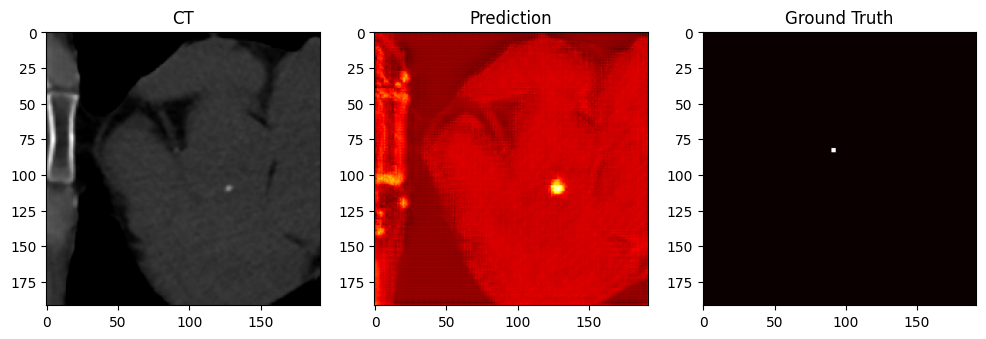

In [ ]:
x, y = next(iter(val_loader))
x = x.to(device)

with torch.no_grad():
    pred = model(x)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(x[0,0].cpu(), cmap="gray")
plt.title("CT")

plt.subplot(1,3,2)
plt.imshow(pred[0,0].cpu(), cmap="hot")
plt.title("Prediction")

plt.subplot(1,3,3)
plt.imshow(y[0,0].cpu(), cmap="hot")
plt.title("Ground Truth")

plt.show()

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = ResUNet().to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/PREDICT-COCA_seg/coca_unet_best_8_march.pth"))
model.eval()

ResUNet(
  (enc1): ResBlock(
    (conv1): Conv2d(2, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (skip): Conv2d(2, 32, kernel_size=(1, 1), stride=(1, 1))
    (relu): ReLU(inplace=True)
  )
  (enc2): ResBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (skip): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
    (relu): ReLU(inplace=True)
  )
  (enc3): ResBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1,

In [ ]:
import random

scan_path = "/content/drive/MyDrive/PREDICT-COCA_seg/data_resampled/e86d325dcd83/e86d325dcd83_img.nii.gz"
print("Selected scan:", scan_path)

Selected scan: /content/drive/MyDrive/PREDICT-COCA_seg/data_resampled/e86d325dcd83/e86d325dcd83_img.nii.gz


In [ ]:
import nibabel as nib

img = nib.load(scan_path).get_fdata()
seg = nib.load(scan_path.replace("_img", "_seg")).get_fdata()
print("Scan shape:", img.shape)
img, seg = roi_crop_3d(img, seg)

Scan shape: (209, 209, 138)


In [ ]:
from ipywidgets import interact
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib

# load segmentation
seg = nib.load(scan_path.replace("_img","_seg")).get_fdata()

def show_slice(z):

    slice_img = img[:,:,z]
    slice_mask = seg[:,:,z]

    # HU mask before normalization
    hu_mask = (slice_img > 130).astype(np.float32)

    # clip HU
    slice_img = np.clip(slice_img,-120,1024)

    # normalize
    slice_norm = (slice_img + 120)/(1024+120)

    # resize
    slice_norm = cv2.resize(slice_norm,(192,192))
    hu_mask = cv2.resize(hu_mask,(192,192))
    slice_mask = cv2.resize(slice_mask,(192,192), interpolation=cv2.INTER_NEAREST)

    # stack channels
    x = np.stack([slice_norm,hu_mask],axis=0)
    x = torch.tensor(x).unsqueeze(0).float().to(device)

    # inference
    with torch.no_grad():
        pred = model(x)

    pred = pred[0,0].cpu().numpy()
    pred_bin = pred > 0.3

    plt.figure(figsize=(16,4))

    plt.subplot(1,4,1)
    plt.imshow(slice_norm,cmap="gray")
    plt.title(f"CT Slice {z}")

    plt.subplot(1,4,2)
    plt.imshow(slice_mask,cmap="hot")
    plt.title("Ground Truth")

    plt.subplot(1,4,3)
    plt.imshow(pred_bin,cmap="hot")
    plt.title("Prediction")

    plt.subplot(1,4,4)
    plt.imshow(slice_norm,cmap="gray")
    plt.imshow(pred_bin,cmap="jet",alpha=0.5)
    plt.title("Overlay")

    plt.show()


interact(show_slice, z=(0, img.shape[2]-1))

interactive(children=(IntSlider(value=68, description='z', max=137), Output()), _dom_classes=('widget-interact…

<function __main__.show_slice(z)>